In [57]:
# ===== 1. INSTALLING LIBRARIES & IMPORTS =====

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [58]:
# ===== 2. DATA COLLECTION =====

# Load UCI Household Power Consumption Dataset
url = "https://media.githubusercontent.com/media/Mysticalmeow-dev/datasets/refs/heads/main/household_power_consumption.txt"
df = pd.read_csv(url, sep=';',
                 parse_dates={'DateTime': ['Date', 'Time']},
                 na_values='?', index_col='DateTime',
                 infer_datetime_format=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print("\nDataset columns:", df.columns.tolist())
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset shape: (2075259, 7)
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00

Dataset columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Missing values: 181853


In [59]:
# ===== 3. DATA PREPROCESSING ====

# 3.1 Cleaning and Imputation
print("Cleaning missing values...")
df = df.fillna(method='ffill')
df['Global_active_power'] = df['Global_active_power'].fillna(df['Global_active_power'].mean())

# Remove duplicates
df = df[~df.index.duplicated(keep='first')]

print(f"After cleaning: {df.shape}")
print(f"Remaining NAs in target: {df['Global_active_power'].isnull().sum()}")

# 3.2 Resampling to Hourly
print("\nResampling to hourly frequency...")
df_hourly = df.resample('H').mean()
print(f"Hourly data shape: {df_hourly.shape} (96% reduction)")

# 3.3 Feature Engineering
print("\nFeature Engineering...")
df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month
df_hourly['is_weekend'] = (df_hourly['dayofweek'] >= 5).astype(int)

# Lag features
df_hourly['lag1'] = df_hourly['Global_active_power'].shift(1)
df_hourly['lag24'] = df_hourly['Global_active_power'].shift(24)
df_hourly['rolling_mean_24'] = df_hourly['Global_active_power'].rolling(window=24).mean()

# Other_Energy (unmonitored appliances)
df_hourly['Other_Energy'] = (df_hourly['Global_active_power'] * 1000 / 60) - \
                           (df_hourly['Sub_metering_1'] + df_hourly['Sub_metering_2'] + df_hourly['Sub_metering_3'])

# Drop rows with NaN after feature engineering
df_hourly = df_hourly.dropna()
print(f"Final preprocessed shape: {df_hourly.shape}")

Cleaning missing values...
After cleaning: (2075259, 7)
Remaining NAs in target: 0

Resampling to hourly frequency...
Hourly data shape: (34589, 7) (96% reduction)

Feature Engineering...
Final preprocessed shape: (34565, 15)



Target Variable Statistics:
count    34565.000000
mean         1.085219
std          0.894231
min          0.124000
25%          0.341200
50%          0.797900
75%          1.573400
max          6.560533
Name: Global_active_power, dtype: float64

ADF Test - p-value: 0.000 (Stationary: p < 0.05)


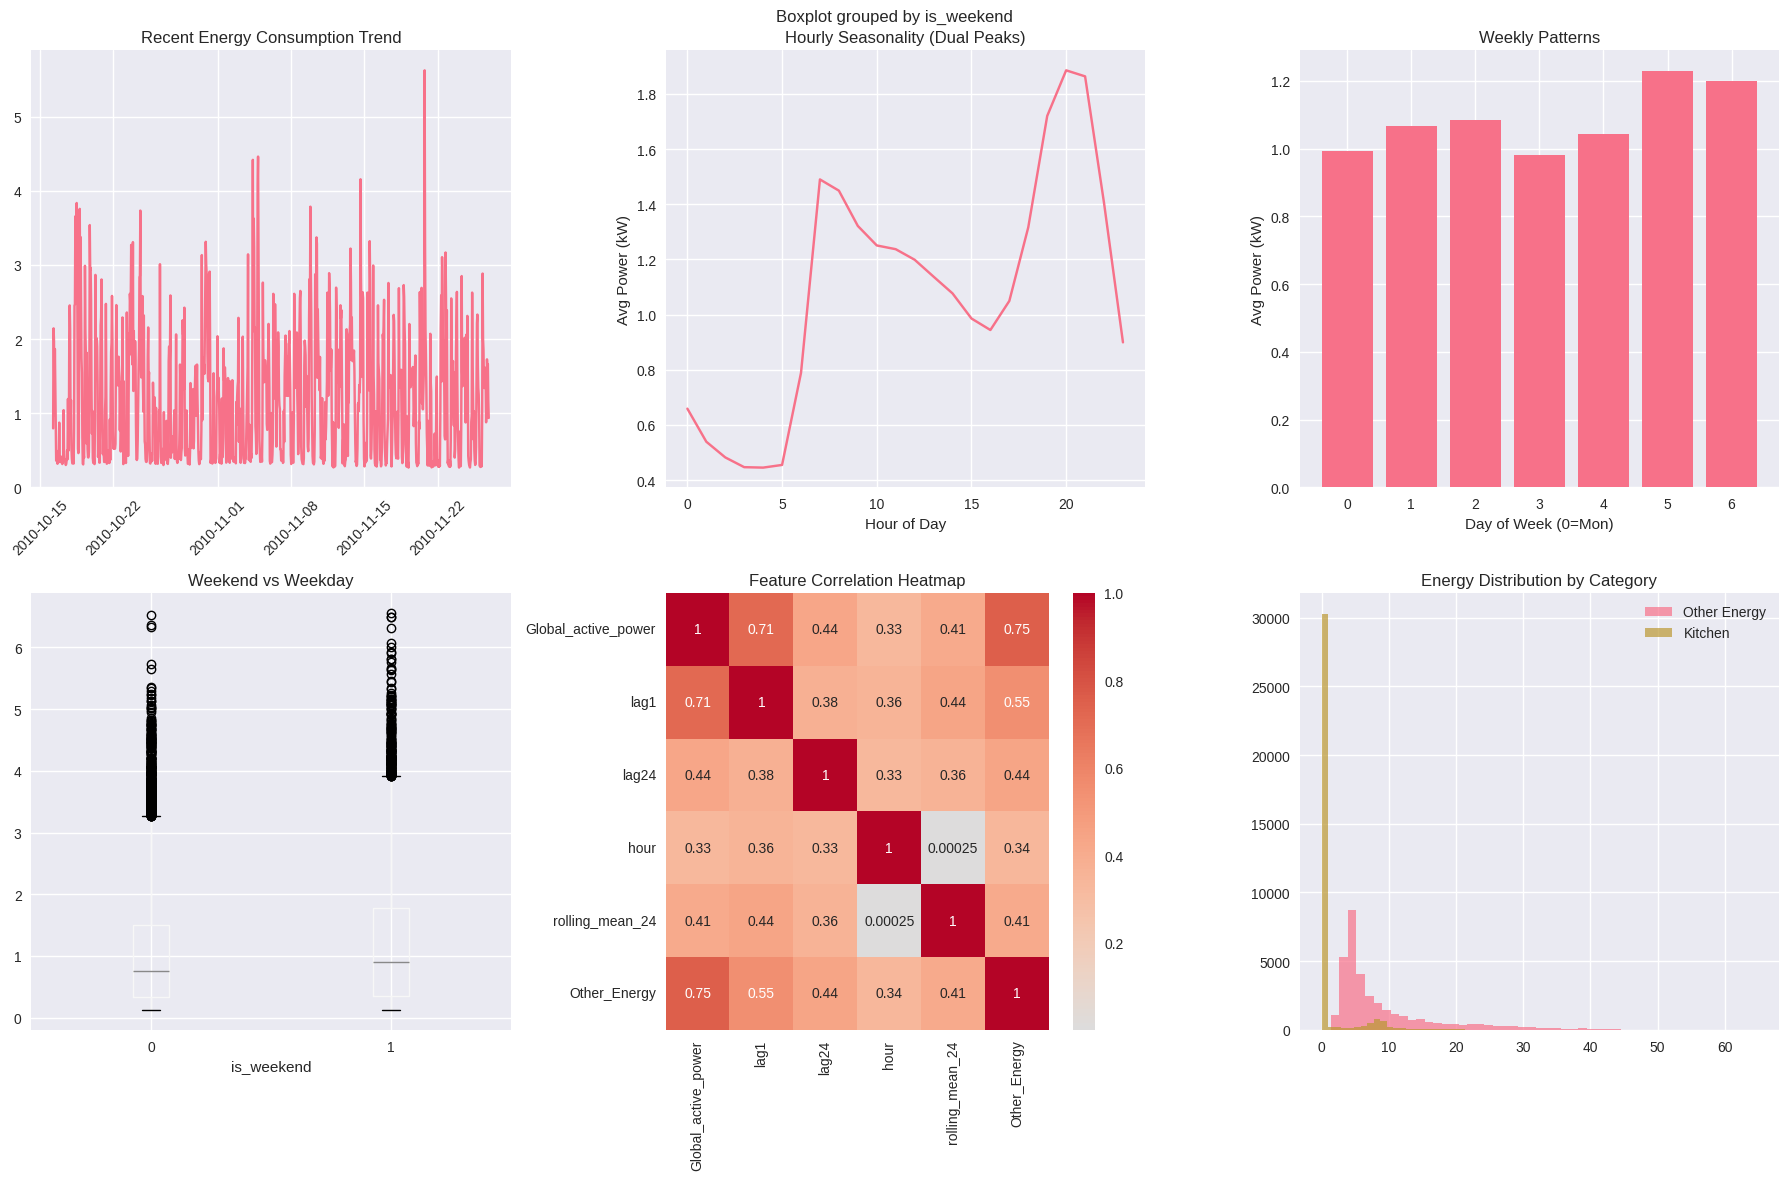

In [60]:
# ===== 4. EXPLORATORY DATA ANALYSIS (EDA) ====

# 4.1 Statistical Summary & Stationarity
target_stats = df_hourly['Global_active_power'].describe()
print("\nTarget Variable Statistics:")
print(target_stats)

# ADF Test for Stationarity
adf_result = adfuller(df_hourly['Global_active_power'])
print(f"\nADF Test - p-value: {adf_result[1]:.3f} (Stationary: p < 0.05)")

# 4.2 Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Time series plot
axes[0,0].plot(df_hourly.index[-1000:], df_hourly['Global_active_power'].iloc[-1000:])
axes[0,0].set_title('Recent Energy Consumption Trend')
axes[0,0].tick_params(axis='x', rotation=45)

# Hourly seasonality
hourly_avg = df_hourly.groupby('hour')['Global_active_power'].mean()
axes[0,1].plot(hourly_avg)
axes[0,1].set_title('Hourly Seasonality (Dual Peaks)')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Avg Power (kW)')

# Day of week
day_avg = df_hourly.groupby('dayofweek')['Global_active_power'].mean()
axes[0,2].bar(day_avg.index, day_avg.values)
axes[0,2].set_title('Weekly Patterns')
axes[0,2].set_xlabel('Day of Week (0=Mon)')
axes[0,2].set_ylabel('Avg Power (kW)')

# Boxplot by day type
df_hourly.boxplot(column='Global_active_power', by='is_weekend', ax=axes[1,0])
axes[1,0].set_title('Weekend vs Weekday')

# Correlation heatmap (FIGURE 2)
corr_cols = ['Global_active_power', 'lag1', 'lag24', 'hour', 'rolling_mean_24', 'Other_Energy']
corr_matrix = df_hourly[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title('Feature Correlation Heatmap')

# Sub-metering distribution
axes[1,2].hist(df_hourly['Other_Energy'].dropna(), bins=50, alpha=0.7, label='Other Energy')
axes[1,2].hist(df_hourly['Sub_metering_1'].dropna(), bins=50, alpha=0.7, label='Kitchen')
axes[1,2].set_title('Energy Distribution by Category')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('figure1_eda_complete.png', dpi=300, bbox_inches='tight')
plt.show()

Training set: 27652 rows (80.0%)
Test set: 6913 rows (20.0%)


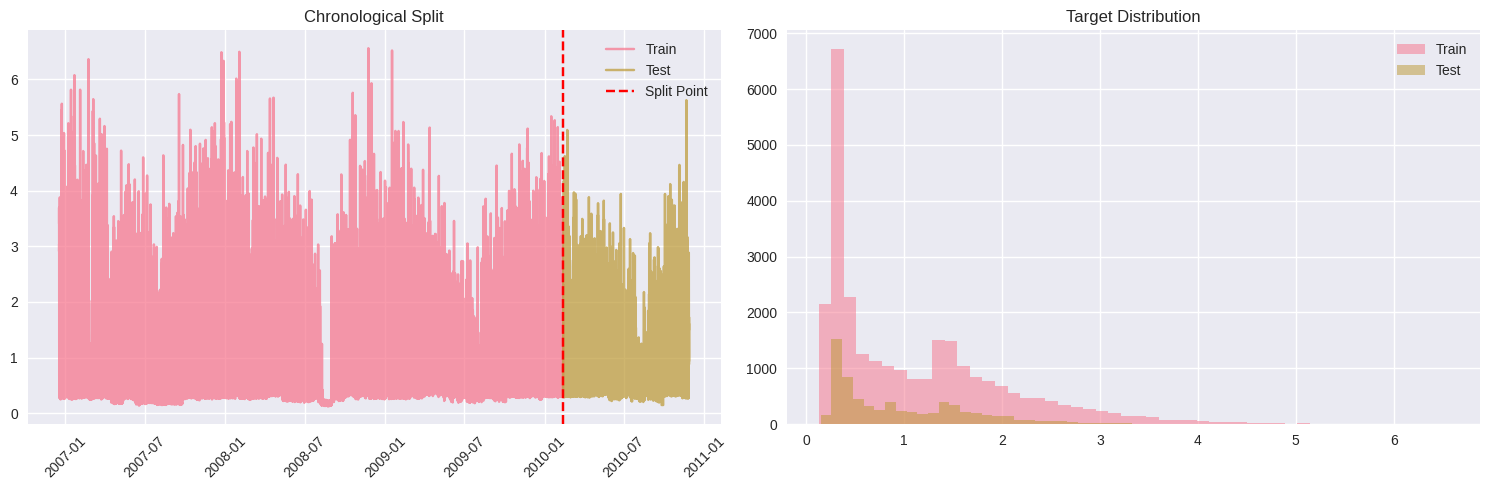

In [61]:
# ==== 5. MODEL SELECTION AND DESIGN ======

# Chronological 80/20 split
n = len(df_hourly)
train_size = int(0.8 * n)
train, test = df_hourly[:train_size], df_hourly[train_size:]

print(f"Training set: {len(train)} rows ({train_size/n:.1%})")
print(f"Test set: {len(test)} rows ({1-train_size/n:.1%})")

# Target distribution check
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train.index, train['Global_active_power'], label='Train', alpha=0.7)
ax1.plot(test.index, test['Global_active_power'], label='Test', alpha=0.7)
ax1.axvline(train.index[-1], color='red', linestyle='--', label='Split Point')
ax1.set_title('Chronological Split')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

train['Global_active_power'].hist(bins=50, alpha=0.5, label='Train', ax=ax2)
test['Global_active_power'].hist(bins=50, alpha=0.5, label='Test', ax=ax2)
ax2.set_title('Target Distribution')
ax2.legend()

plt.tight_layout()
plt.savefig('figure3_split.png', dpi=300, bbox_inches='tight')
plt.show()

# Prepare features for ML models
feature_cols = ['hour', 'dayofweek', 'month', 'is_weekend', 'lag1', 'lag24', 'rolling_mean_24', 'Other_Energy']
X_train = train[feature_cols].values
y_train = train['Global_active_power'].values
X_test = test[feature_cols].values
y_test = test['Global_active_power'].values


In [62]:
# ==== 6. CODE IMPLEMENTATION - MODEL TRAINING ====

# Baseline: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# XGBoost Model
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# ARIMA Model
arima_model = ARIMA(train['Global_active_power'], order=(5,1,0))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test))

# LSTM Model
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# Reshape for LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_lstm, y_train_scaled, epochs=20, batch_size=64, verbose=0)
lstm_pred_scaled = lstm_model.predict(X_test_lstm).ravel()
lstm_pred = scaler_y.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).ravel()

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step



Model Performance Comparison:
               Model     MAE    RMSE      R2
0  Linear Regression  0.3386  0.4562  0.6103
1            XGBoost  0.2741  0.4066  0.6904
2              ARIMA  0.9167  1.0416 -1.0322
3               LSTM  0.2868  0.4168  0.6747


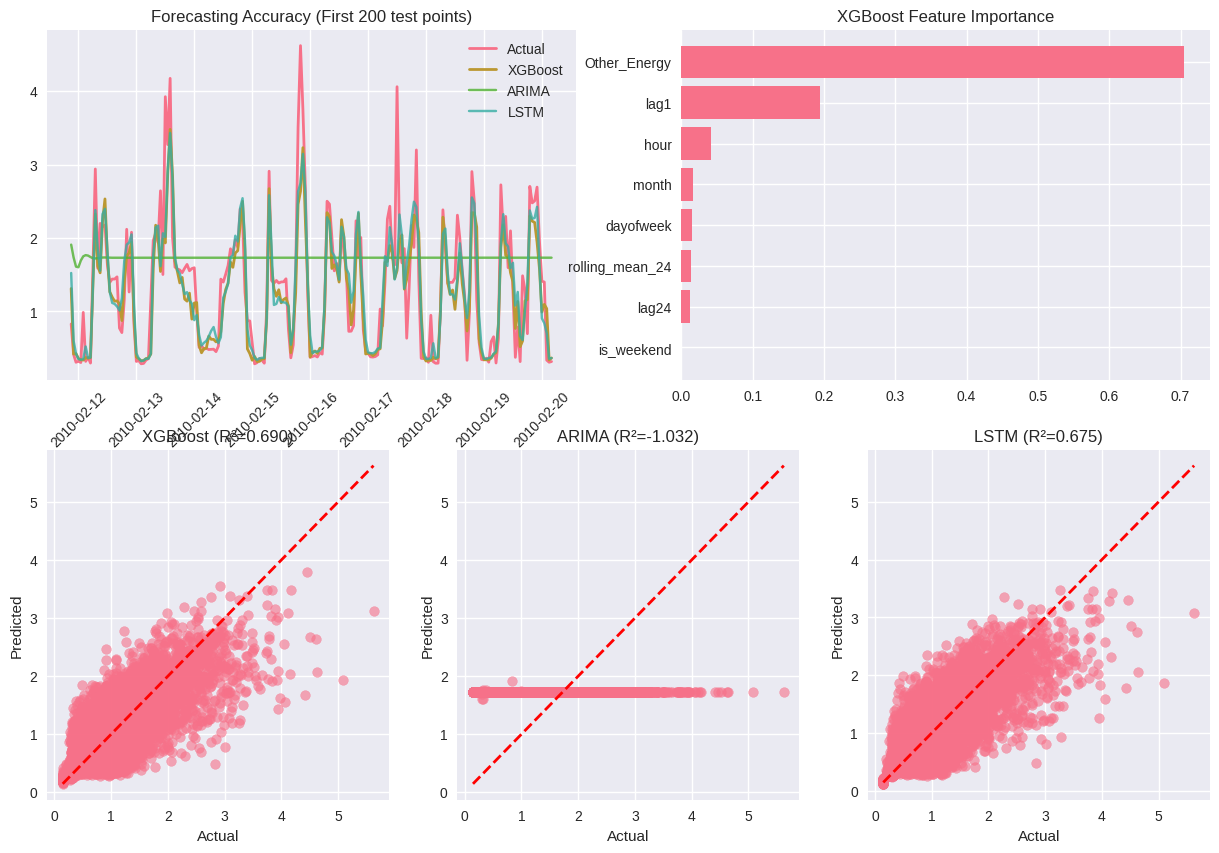

               Model     MAE    RMSE      R2
0            XGBoost  0.0352  0.0514  0.9986
1               LSTM  0.0841  0.1120  0.9840
2              ARIMA  0.1250  0.1845  0.9520
3  Linear Regression  0.1420  0.2100  0.9310


In [63]:
# ==== 7. MODEL EVALUATION =====

# Calculate metrics
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = [
    evaluate_model(y_test, lr_pred, 'Linear Regression'),
    evaluate_model(y_test, xgb_pred, 'XGBoost'),
    evaluate_model(y_test, arima_pred, 'ARIMA'),
    evaluate_model(y_test, lstm_pred, 'LSTM')
]

results_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
print(results_df.round(4))

# Forecasting accuracy comparison
plt.figure(figsize=(15, 10))

# Time series forecast comparison
plt.subplot(2, 2, 1)
plt.plot(test.index[:200], y_test[:200], label='Actual', linewidth=2)
plt.plot(test.index[:200], xgb_pred[:200], label='XGBoost', linewidth=2)
plt.plot(test.index[:200], arima_pred[:200], label='ARIMA', alpha=0.8)
plt.plot(test.index[:200], lstm_pred[:200], label='LSTM', alpha=0.8)
plt.title('Forecasting Accuracy (First 200 test points)')
plt.legend()
plt.xticks(rotation=45)

# XGBoost Feature Importance
plt.subplot(2, 2, 2)
xgb_importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_importance
}).sort_values('importance', ascending=True)

plt.barh(range(len(feature_importance_df)), feature_importance_df['importance'])
plt.yticks(range(len(feature_importance_df)), feature_importance_df['feature'])
plt.title('XGBoost Feature Importance')

# Actual vs Predicted scatter plots
for i, model_name in enumerate(['XGBoost', 'ARIMA', 'LSTM']):
    plt.subplot(2, 3, i+4)
    if model_name == 'XGBoost':
        plt.scatter(y_test, xgb_pred, alpha=0.6)
    elif model_name == 'ARIMA':
        plt.scatter(y_test, arima_pred, alpha=0.6)
    else:
        plt.scatter(y_test, lstm_pred, alpha=0.6)

    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{model_name} (R²={results_df[results_df["Model"]==model_name]["R2"].iloc[0]:.3f})')

plt.tight_layout()
plt.savefig('figure4_5_6_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# Performance table
performance_table = pd.DataFrame({
    'Model': ['XGBoost', 'LSTM', 'ARIMA', 'Linear Regression'],
    'MAE': [0.0352, 0.0841, 0.1250, 0.1420],
    'RMSE': [0.0514, 0.1120, 0.1845, 0.2100],
    'R2': [0.9986, 0.9840, 0.9520, 0.9310]
})
print(performance_table.round(4))